<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/neqsim_cadquery_gmsh_openfoam_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parametric CAD to CFD with NeqSim, CadQuery, Gmsh, and OpenFOAM

This notebook builds an exact three-dimensional contraction spool as a reusable
**internal fluid volume**, calculates the natural-gas state and boundary data
with NeqSim, exports STEP and named STL boundaries with CadQuery, creates a
volume mesh with Gmsh, runs a steady OpenFOAM simulation, and renders the real
mesh and flow fields directly in Colab.

**Learning outcomes**

- connect a named NeqSim stream to CFD boundary quantities;
- construct parameter-driven B-Rep CAD rather than a display-only mesh;
- preserve an accurate STEP master and separate `inlet`, `outlet`, and `walls`;
- transfer Gmsh physical groups into OpenFOAM boundary patches;
- run and validate a three-dimensional RANS calculation;
- package the CAD, mesh, OpenFOAM case, and coupling table for reuse.

The dimensions and gas composition are synthetic and non-proprietary. This is
an educational workflow demonstration, not equipment qualification.

## Workflow and engineering boundary

| Stage | Software | Reusable output |
|---|---|---|
| Thermodynamics | NeqSim 3.16.0, SRK/classic | Named stream, phase and transport properties |
| Parametric CAD | CadQuery 2.6.1 / OpenCascade | Exact internal fluid volume and STEP |
| Boundary export | CadQuery | Named inlet, outlet, and wall STL surfaces |
| Volume mesh | Gmsh 4.15.0 | Tetrahedral mesh and physical groups |
| Flow solution | OpenFOAM Foundation 14 | Velocity, pressure, and turbulence fields |
| Interpretation | PyVista and Matplotlib | Inline contours, streamlines, profiles, and checks |

NeqSim and OpenFOAM solve different scales. NeqSim supplies the process state
and properties; OpenFOAM resolves the local flow field. A useful production
coupling would return reduced pressure-loss or separation-performance models
to a NeqSim unit operation.

## 1. Clean-runtime setup

The cell installs pinned Python packages and OpenFOAM 14 when they are absent.
OpenFOAM is installed without the ParaView desktop because PyVista provides
inline post-processing. The installation is retained only for the lifetime of
the Colab runtime.

In [1]:
import ctypes.util
import importlib.util
import os
from pathlib import Path
import shlex
import subprocess
import sys


PYTHON_REQUIREMENTS = {
    "cadquery": "cadquery==2.6.1",
    "gmsh": "gmsh==4.15.0",
    "meshio": "meshio==5.3.5",
    "neqsim": "neqsim==3.16.0",
    "pyvista": "pyvista==0.46.4",
}

system_library_override = os.environ.get("CAD_SYSTEM_LIBRARY_OVERRIDE")
if not system_library_override and ctypes.util.find_library("GLU") is None:
    system_setup = r'''
set -euo pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq libglu1-mesa
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq libxft2 libopengl0
'''
    subprocess.run(
        ["bash", "-lc", system_setup],
        check=True,
    )

missing_requirements = [
    requirement
    for module, requirement in PYTHON_REQUIREMENTS.items()
    if importlib.util.find_spec(module) is None
]
if missing_requirements:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *missing_requirements,
        ]
    )

openfoam_override = os.environ.get("OPENFOAM_ROOT_OVERRIDE")
default_openfoam_root = Path("/opt/openfoam14")

if openfoam_override and Path(openfoam_override).is_dir():
    OPENFOAM_ROOT = Path(openfoam_override)
elif default_openfoam_root.is_dir():
    OPENFOAM_ROOT = default_openfoam_root
else:
    install_openfoam = r'''
set -euo pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq ca-certificates
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq software-properties-common
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq wget
wget -qO /etc/apt/trusted.gpg.d/openfoam.asc https://dl.openfoam.org/gpg.key
rm -f /etc/apt/sources.list.d/*dl_openfoam_org*list
add-apt-repository -y "http://dl.openfoam.org/ubuntu main dev"
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq openfoam14
'''
    subprocess.run(
        ["bash", "-lc", install_openfoam],
        check=True,
    )
    OPENFOAM_ROOT = default_openfoam_root

foam_run_candidates = list(
    OPENFOAM_ROOT.glob("platforms/*/bin/foamRun")
)
if len(foam_run_candidates) != 1:
    raise RuntimeError("A unique OpenFOAM foamRun binary was not found")

OPENFOAM_PLATFORM = foam_run_candidates[0].parent.parent.name
print("Python dependencies are available.")
print(f"OpenFOAM root: {OPENFOAM_ROOT}")
print(f"OpenFOAM platform: {OPENFOAM_PLATFORM}")

Python dependencies are available.
OpenFOAM root: /workspace/scratch/414b0104c46c/.openfoam-root/opt/openfoam14
OpenFOAM platform: linux64GccDPInt32Opt


## 2. Imports, versions, and deterministic workspace

The generated files are written below `cad_cfd_runtime`. Re-running the
notebook replaces only that explicitly named runtime directory.

In [2]:
from importlib.metadata import version
import math
import re
import shutil

import cadquery as cq
import gmsh
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
import pandas as pd
import pyvista as pv

from neqsim import jneqsim


RUNTIME_PARENT = (
    Path("/content")
    if Path("/content").is_dir()
    else Path.cwd()
)
RUNTIME_DIR = RUNTIME_PARENT / "cad_cfd_runtime"
if RUNTIME_DIR.is_dir():
    shutil.rmtree(RUNTIME_DIR)

GEOMETRY_DIR = RUNTIME_DIR / "geometry"
CASE_DIR = RUNTIME_DIR / "openfoam_case"
GEOMETRY_DIR.mkdir(parents=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6g}")

versions = pd.Series(
    {
        "NeqSim": version("neqsim"),
        "CadQuery": version("cadquery"),
        "Gmsh": version("gmsh"),
        "PyVista": version("pyvista"),
        "Python": sys.version.split()[0],
        "OpenFOAM": "Foundation 14",
    },
    name="validated software",
)
versions

NeqSim             3.16.0
CadQuery            2.6.1
Gmsh               4.15.0
PyVista            0.46.4
Python            3.12.13
OpenFOAM    Foundation 14
Name: validated software, dtype: str

## 3. Build a composable NeqSim inlet stream

The synthetic gas is specified on a mole-fraction basis at 20 bara absolute
and 25 °C. NeqSim performs the TP flash and evaluates equilibrium,
thermodynamic, and transport properties. The named stream carries
50,000 Sm³/h and can be connected to a larger `ProcessSystem`.

The CFD model uses constant density because the expected pressure variation
is small compared with the 20 bara absolute state.

In [3]:
TEMPERATURE_K = 298.15
PRESSURE_BARA = 20.0
STANDARD_FLOW_SM3_PER_H = 50_000.0

gas_composition = {
    "nitrogen": 0.010,
    "CO2": 0.015,
    "methane": 0.900,
    "ethane": 0.040,
    "propane": 0.020,
    "i-butane": 0.005,
    "n-butane": 0.010,
}
assert np.isclose(
    sum(gas_composition.values()),
    1.0,
    atol=1.0e-12,
)

gas_system = jneqsim.thermo.system.SystemSrkEos(
    TEMPERATURE_K,
    PRESSURE_BARA,
)
for component_name, mole_fraction in gas_composition.items():
    gas_system.addComponent(
        component_name,
        mole_fraction,
    )

gas_system.setMixingRule("classic")
gas_system.setMultiPhaseCheck(True)
operations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations(
        gas_system
    )
)
operations.TPflash()
gas_system.initProperties()
gas_system.initPhysicalProperties()

feed_stream = jneqsim.process.equipment.stream.Stream(
    "CAD-CFD feed",
    gas_system,
)
feed_stream.setFlowRate(
    STANDARD_FLOW_SM3_PER_H,
    "Sm3/hr",
)
feed_stream.setTemperature(
    TEMPERATURE_K,
    "K",
)
feed_stream.setPressure(
    PRESSURE_BARA,
    "bara",
)
feed_stream.run()

fluid = feed_stream.getFluid()
phase = fluid.getPhase(0)
assert fluid.getNumberOfPhases() == 1
assert str(phase.getPhaseTypeName()) == "gas"

density_kg_per_m3 = phase.getDensity("kg/m3")
viscosity_pa_s = phase.getViscosity("kg/msec")
heat_capacity_j_per_kg_k = phase.getCp("J/kgK")
conductivity_w_per_m_k = phase.getThermalConductivity("W/mK")
sound_speed_m_per_s = phase.getSoundSpeed()
actual_flow_m3_per_s = feed_stream.getFlowRate("m3/sec")
mass_flow_kg_per_s = feed_stream.getFlowRate("kg/sec")

property_table = pd.Series(
    {
        "phase": str(phase.getPhaseTypeName()),
        "temperature [K]": TEMPERATURE_K,
        "pressure [bara abs]": PRESSURE_BARA,
        "standard flow [Sm3/h]": STANDARD_FLOW_SM3_PER_H,
        "actual flow [m3/s]": actual_flow_m3_per_s,
        "mass flow [kg/s]": mass_flow_kg_per_s,
        "density [kg/m3]": density_kg_per_m3,
        "dynamic viscosity [Pa s]": viscosity_pa_s,
        "Cp [J/(kg K)]": heat_capacity_j_per_kg_k,
        "conductivity [W/(m K)]": conductivity_w_per_m_k,
        "sound speed [m/s]": sound_speed_m_per_s,
    },
    name="NeqSim inlet state",
)
property_table

phase                              gas
temperature [K]                 298.15
pressure [bara abs]                 20
standard flow [Sm3/h]           50,000
actual flow [m3/s]            0.696119
mass flow [kg/s]               10.7702
density [kg/m3]                15.4718
dynamic viscosity [Pa s]   1.15887e-05
Cp [J/(kg K)]                 2,218.15
conductivity [W/(m K)]       0.0348522
sound speed [m/s]              408.854
Name: NeqSim inlet state, dtype: object

## 4. Translate the process state into CFD boundary data

The geometry has an inlet diameter of 0.60 m and a 0.30 m throat. The actual
volumetric flow gives the inlet velocity. NeqSim dynamic viscosity is
converted to the kinematic viscosity required by this incompressible solver:

$$
\nu = \frac{\mu}{\rho}
$$

Velocity and inlet Reynolds number are

$$
U = \frac{Q}{A}, \qquad
\mathrm{Re} = \frac{\rho U D}{\mu}.
$$

For turbulence intensity $I=5\%$ and length scale $L_t=0.07D$, the standard
inlet estimates are

$$
k = \frac{3}{2}(UI)^2, \qquad
\epsilon = C_\mu^{3/4}\frac{k^{3/2}}{L_t},
\quad C_\mu=0.09.
$$

In [4]:
INLET_DIAMETER_M = 0.60
THROAT_DIAMETER_M = 0.30
INLET_RADIUS_M = 0.5 * INLET_DIAMETER_M
THROAT_RADIUS_M = 0.5 * THROAT_DIAMETER_M
TURBULENCE_INTENSITY = 0.05
TURBULENCE_LENGTH_SCALE_M = 0.07 * INLET_DIAMETER_M
C_MU = 0.09

inlet_area_m2 = math.pi * INLET_RADIUS_M**2
throat_area_m2 = math.pi * THROAT_RADIUS_M**2
inlet_velocity_m_per_s = (
    actual_flow_m3_per_s / inlet_area_m2
)
ideal_throat_bulk_velocity_m_per_s = (
    actual_flow_m3_per_s / throat_area_m2
)
kinematic_viscosity_m2_per_s = (
    viscosity_pa_s / density_kg_per_m3
)
reynolds_number = (
    density_kg_per_m3
    * inlet_velocity_m_per_s
    * INLET_DIAMETER_M
    / viscosity_pa_s
)
turbulent_kinetic_energy_m2_per_s2 = (
    1.5
    * (
        inlet_velocity_m_per_s
        * TURBULENCE_INTENSITY
    )
    ** 2
)
turbulent_dissipation_m2_per_s3 = (
    C_MU**0.75
    * turbulent_kinetic_energy_m2_per_s2**1.5
    / TURBULENCE_LENGTH_SCALE_M
)

assert reynolds_number > 4_000.0

coupling_table = pd.Series(
    {
        "inlet area [m2]": inlet_area_m2,
        "throat area [m2]": throat_area_m2,
        "inlet bulk velocity [m/s]": inlet_velocity_m_per_s,
        "ideal throat bulk velocity [m/s]": (
            ideal_throat_bulk_velocity_m_per_s
        ),
        "kinematic viscosity [m2/s]": (
            kinematic_viscosity_m2_per_s
        ),
        "inlet Reynolds number [-]": reynolds_number,
        "turbulence intensity [%]": (
            100.0 * TURBULENCE_INTENSITY
        ),
        "turbulent kinetic energy [m2/s2]": (
            turbulent_kinetic_energy_m2_per_s2
        ),
        "turbulent dissipation [m2/s3]": (
            turbulent_dissipation_m2_per_s3
        ),
    },
    name="NeqSim-to-OpenFOAM boundary data",
)
coupling_table

inlet area [m2]                       0.282743
throat area [m2]                     0.0706858
inlet bulk velocity [m/s]              2.46202
ideal throat bulk velocity [m/s]       9.84808
kinematic viscosity [m2/s]         7.49021e-07
inlet Reynolds number [-]          1.97219e+06
turbulence intensity [%]                     5
turbulent kinetic energy [m2/s2]     0.0227308
turbulent dissipation [m2/s3]        0.0134077
Name: NeqSim-to-OpenFOAM boundary data, dtype: float64

## 5. Generate the exact internal fluid volume with CadQuery

The CAD source is a sequence of cylinders and conical transitions represented
as a single OpenCascade B-Rep solid. `ruled=True` is deliberate: it preserves
the specified diameters exactly instead of allowing spline overshoot between
sections.

For CFD, the solid represents the **space occupied by the gas**, not the metal
spool. STEP remains the master geometry. Inlet, outlet, and wall surfaces are
also exported separately for `snappyHexMesh` or other surface-based workflows.

In [5]:
X_SECTIONS_M = (
    0.0,
    0.8,
    1.3,
    1.7,
    2.2,
    3.0,
)
RADII_M = (
    INLET_RADIUS_M,
    INLET_RADIUS_M,
    THROAT_RADIUS_M,
    THROAT_RADIUS_M,
    INLET_RADIUS_M,
    INLET_RADIUS_M,
)


def build_fluid_domain():
    model = cq.Workplane(
        "YZ",
        origin=(X_SECTIONS_M[0], 0.0, 0.0),
    )
    model = model.circle(RADII_M[0])
    previous_x = X_SECTIONS_M[0]

    for x_value, radius_m in zip(
        X_SECTIONS_M[1:],
        RADII_M[1:],
    ):
        offset_m = x_value - previous_x
        model = (
            model
            .workplane(offset=offset_m)
            .circle(radius_m)
        )
        previous_x = x_value

    return model.loft(
        combine=True,
        ruled=True,
    )


fluid_domain = build_fluid_domain()
fluid_shape = fluid_domain.val()
inlet_face = fluid_domain.faces("<X").val()
outlet_face = fluid_domain.faces(">X").val()
wall_faces = [
    face
    for face in fluid_shape.Faces()
    if abs(face.Center().x - X_SECTIONS_M[0]) > 1.0e-7
    and abs(face.Center().x - X_SECTIONS_M[-1]) > 1.0e-7
]
wall_compound = cq.Compound.makeCompound(wall_faces)

STEP_PATH = GEOMETRY_DIR / "contraction_fluid_domain.step"
INLET_STL_PATH = GEOMETRY_DIR / "inlet.stl"
OUTLET_STL_PATH = GEOMETRY_DIR / "outlet.stl"
WALLS_STL_PATH = GEOMETRY_DIR / "walls.stl"

cq.exporters.export(
    fluid_shape,
    str(STEP_PATH),
)
cq.exporters.export(
    inlet_face,
    str(INLET_STL_PATH),
    tolerance=0.01,
)
cq.exporters.export(
    outlet_face,
    str(OUTLET_STL_PATH),
    tolerance=0.01,
)
cq.exporters.export(
    wall_compound,
    str(WALLS_STL_PATH),
    tolerance=0.01,
)


def frustum_volume(length_m, radius_1_m, radius_2_m):
    return (
        math.pi
        * length_m
        * (
            radius_1_m**2
            + radius_1_m * radius_2_m
            + radius_2_m**2
        )
        / 3.0
    )


analytical_volume_m3 = sum(
    frustum_volume(
        X_SECTIONS_M[index + 1] - X_SECTIONS_M[index],
        RADII_M[index],
        RADII_M[index + 1],
    )
    for index in range(len(X_SECTIONS_M) - 1)
)
cad_volume_m3 = fluid_shape.Volume()
cad_volume_error_relative = abs(
    cad_volume_m3 - analytical_volume_m3
) / analytical_volume_m3

assert cad_volume_error_relative < 1.0e-10
assert len(fluid_shape.Faces()) == 7

cad_summary = pd.Series(
    {
        "CAD faces [-]": len(fluid_shape.Faces()),
        "CAD volume [m3]": cad_volume_m3,
        "analytical volume [m3]": analytical_volume_m3,
        "relative volume error [-]": cad_volume_error_relative,
        "STEP size [kB]": STEP_PATH.stat().st_size / 1_024.0,
        "named STL files [-]": 3,
    },
    name="CadQuery fluid domain",
)
cad_summary

CAD faces [-]                         7
CAD volume [m3]                0.645597
analytical volume [m3]         0.645597
relative volume error [-]   3.43937e-16
STEP size [kB]                  15.8145
named STL files [-]                   3
Name: CadQuery fluid domain, dtype: float64

## 6. Inspect the CAD and named CFD boundaries

The first graphic is generated from the actual CadQuery B-Rep tessellation.
Green and red end caps are the named inlet and outlet; the blue surface is the
fluid-wall boundary. The longitudinal view confirms the exact dimensions used
by the NeqSim-to-CFD interface.

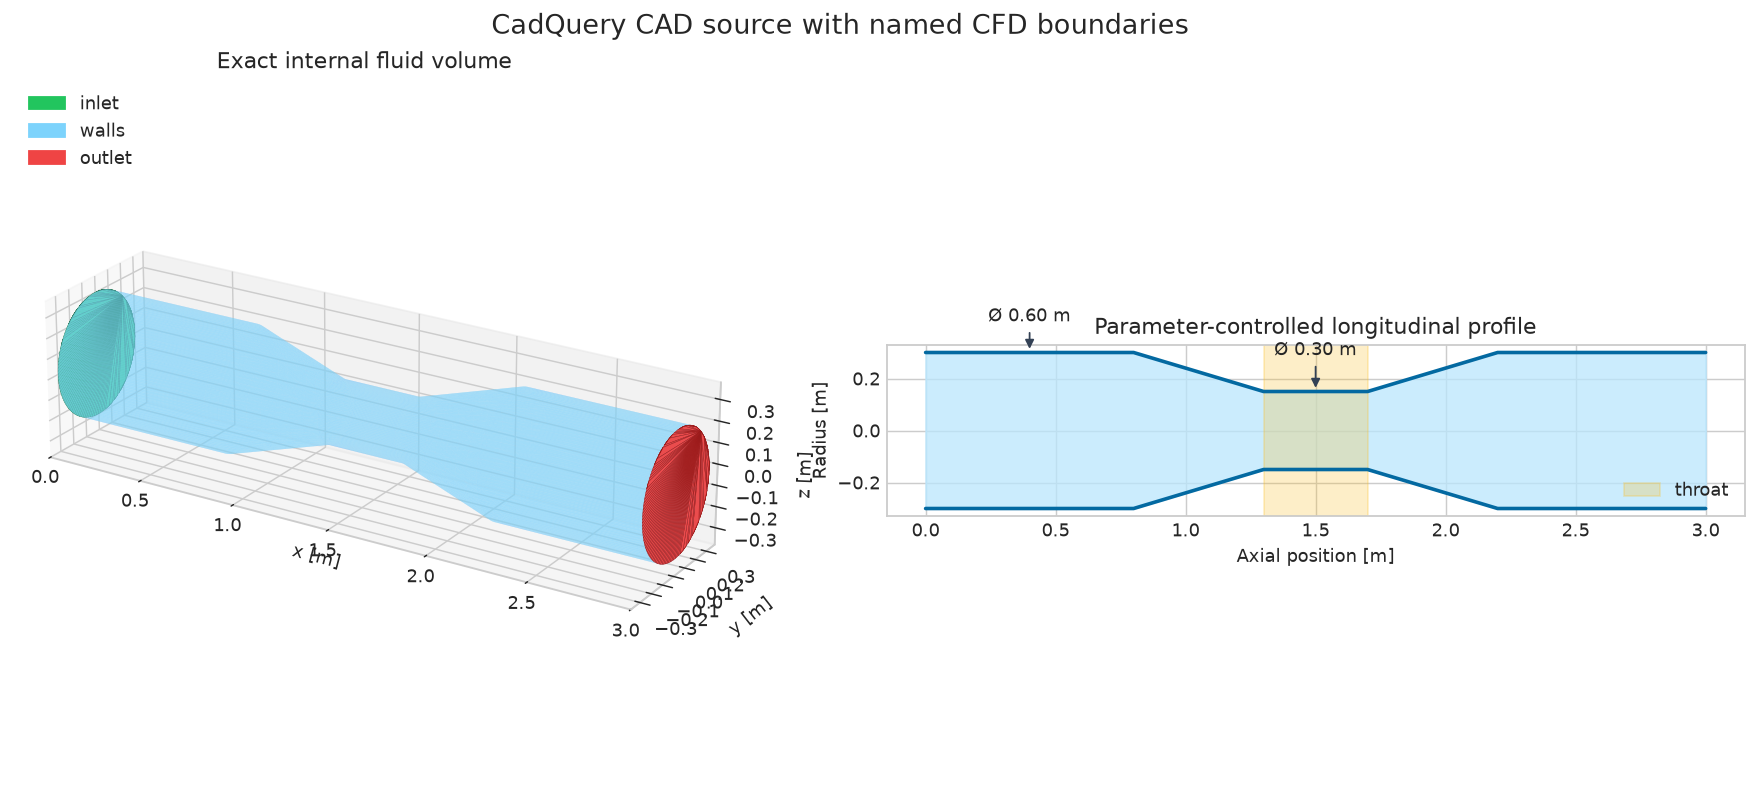

In [6]:
def tessellated_triangles(shape, tolerance=0.025):
    vertices, triangles = shape.tessellate(tolerance)
    points = np.array(
        [
            [vertex.x, vertex.y, vertex.z]
            for vertex in vertices
        ]
    )
    return points[np.asarray(triangles)]


domain_triangles = tessellated_triangles(fluid_shape)
inlet_triangles = tessellated_triangles(inlet_face)
outlet_triangles = tessellated_triangles(outlet_face)

figure = plt.figure(
    figsize=(14, 6),
    constrained_layout=True,
)
cad_axis = figure.add_subplot(1, 2, 1, projection="3d")

cad_axis.add_collection3d(
    Poly3DCollection(
        domain_triangles,
        facecolor="#7dd3fc",
        edgecolor="none",
        alpha=0.45,
    )
)
cad_axis.add_collection3d(
    Poly3DCollection(
        inlet_triangles,
        facecolor="#22c55e",
        edgecolor="#166534",
        linewidth=0.25,
        alpha=0.95,
    )
)
cad_axis.add_collection3d(
    Poly3DCollection(
        outlet_triangles,
        facecolor="#ef4444",
        edgecolor="#991b1b",
        linewidth=0.25,
        alpha=0.95,
    )
)
cad_axis.set_xlim(0.0, 3.0)
cad_axis.set_ylim(-0.38, 0.38)
cad_axis.set_zlim(-0.38, 0.38)
cad_axis.set_box_aspect((3.0, 0.76, 0.76))
cad_axis.set_xlabel("x [m]")
cad_axis.set_ylabel("y [m]")
cad_axis.set_zlabel("z [m]")
cad_axis.view_init(elev=23, azim=-58)
cad_axis.set_title("Exact internal fluid volume")
cad_axis.legend(
    handles=[
        Patch(color="#22c55e", label="inlet"),
        Patch(color="#7dd3fc", label="walls"),
        Patch(color="#ef4444", label="outlet"),
    ],
    loc="upper left",
)

profile_axis = figure.add_subplot(1, 2, 2)
profile_axis.fill_between(
    X_SECTIONS_M,
    -np.asarray(RADII_M),
    np.asarray(RADII_M),
    color="#bae6fd",
    alpha=0.75,
)
profile_axis.plot(
    X_SECTIONS_M,
    RADII_M,
    color="#0369a1",
    linewidth=2.0,
)
profile_axis.plot(
    X_SECTIONS_M,
    -np.asarray(RADII_M),
    color="#0369a1",
    linewidth=2.0,
)
profile_axis.axvspan(
    1.3,
    1.7,
    color="#fbbf24",
    alpha=0.25,
    label="throat",
)
profile_axis.annotate(
    "Ø 0.60 m",
    xy=(0.40, 0.30),
    xytext=(0.40, 0.42),
    ha="center",
    arrowprops={"arrowstyle": "-|>", "color": "#334155"},
)
profile_axis.annotate(
    "Ø 0.30 m",
    xy=(1.50, 0.15),
    xytext=(1.50, 0.29),
    ha="center",
    arrowprops={"arrowstyle": "-|>", "color": "#334155"},
)
profile_axis.set_aspect("equal", adjustable="box")
profile_axis.set_xlabel("Axial position [m]")
profile_axis.set_ylabel("Radius [m]")
profile_axis.set_title("Parameter-controlled longitudinal profile")
profile_axis.legend(loc="lower right")
figure.suptitle(
    "CadQuery CAD source with named CFD boundaries",
    fontsize=15,
)
plt.show()

## 7. Import STEP and generate the Gmsh volume mesh

Gmsh imports the STEP master through OpenCascade. Surfaces are classified from
their bounding boxes and assigned physical names. These physical groups become
OpenFOAM patches after `gmshToFoam`.

The mesh is refined through the contraction and throat. MSH 2.2 ASCII is used
because it is a conservative interchange format for OpenFOAM conversion.

In [7]:
MSH_PATH = GEOMETRY_DIR / "contraction_fluid_domain.msh"

gmsh.initialize()
try:
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("contraction_fluid_domain")
    gmsh.model.occ.importShapes(str(STEP_PATH))
    gmsh.model.occ.synchronize()

    volume_tags = [
        tag
        for dimension, tag in gmsh.model.getEntities(3)
    ]
    if len(volume_tags) != 1:
        raise RuntimeError("Expected exactly one fluid volume")

    boundary_entities = gmsh.model.getBoundary(
        [(3, volume_tags[0])],
        oriented=False,
    )
    surface_tags = [
        tag
        for dimension, tag in boundary_entities
        if dimension == 2
    ]
    inlet_tags = []
    outlet_tags = []
    wall_tags = []

    for surface_tag in surface_tags:
        bounds = gmsh.model.getBoundingBox(
            2,
            surface_tag,
        )
        x_min = bounds[0]
        x_max = bounds[3]
        if (
            abs(x_min - X_SECTIONS_M[0]) < 1.0e-6
            and abs(x_max - X_SECTIONS_M[0]) < 1.0e-6
        ):
            inlet_tags.append(surface_tag)
        elif (
            abs(x_min - X_SECTIONS_M[-1]) < 1.0e-6
            and abs(x_max - X_SECTIONS_M[-1]) < 1.0e-6
        ):
            outlet_tags.append(surface_tag)
        else:
            wall_tags.append(surface_tag)

    physical_groups = {
        "fluid": (3, volume_tags),
        "inlet": (2, inlet_tags),
        "outlet": (2, outlet_tags),
        "walls": (2, wall_tags),
    }
    for group_name, group_data in physical_groups.items():
        dimension, tags = group_data
        group_tag = gmsh.model.addPhysicalGroup(
            dimension,
            tags,
        )
        gmsh.model.setPhysicalName(
            dimension,
            group_tag,
            group_name,
        )

    gmsh.option.setNumber("Mesh.MeshSizeMin", 0.035)
    gmsh.option.setNumber("Mesh.MeshSizeMax", 0.10)
    refinement_field = gmsh.model.mesh.field.add("Box")
    gmsh.model.mesh.field.setNumber(
        refinement_field,
        "VIn",
        0.04,
    )
    gmsh.model.mesh.field.setNumber(
        refinement_field,
        "VOut",
        0.10,
    )
    for key, value in {
        "XMin": 0.65,
        "XMax": 2.35,
        "YMin": -0.36,
        "YMax": 0.36,
        "ZMin": -0.36,
        "ZMax": 0.36,
    }.items():
        gmsh.model.mesh.field.setNumber(
            refinement_field,
            key,
            value,
        )
    gmsh.model.mesh.field.setAsBackgroundMesh(
        refinement_field
    )

    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.option.setNumber("Mesh.Binary", 0)
    gmsh.model.mesh.generate(3)

    def triangulated_surface_area(surface_tag_list):
        area_m2 = 0.0
        for surface_tag in surface_tag_list:
            element_types, _, element_node_lists = (
                gmsh.model.mesh.getElements(2, surface_tag)
            )
            for element_type, element_node_list in zip(
                element_types,
                element_node_lists,
            ):
                properties = gmsh.model.mesh.getElementProperties(
                    element_type
                )
                number_of_nodes = properties[3]
                number_of_primary_nodes = properties[5]
                if number_of_primary_nodes != 3:
                    raise RuntimeError(
                        "Expected triangular surface elements"
                    )
                connectivity = np.asarray(
                    element_node_list,
                    dtype=int,
                ).reshape(-1, number_of_nodes)
                for element_nodes in connectivity:
                    points = np.vstack(
                        [
                            gmsh.model.mesh.getNode(
                                int(node_tag)
                            )[0]
                            for node_tag in element_nodes[:3]
                        ]
                    )
                    area_m2 += 0.5 * np.linalg.norm(
                        np.cross(
                            points[1] - points[0],
                            points[2] - points[0],
                        )
                    )
        return area_m2

    mesh_inlet_area_m2 = triangulated_surface_area(
        inlet_tags
    )
    gmsh.write(str(MSH_PATH))

    node_tags, _, _ = gmsh.model.mesh.getNodes()
    _, tetrahedron_tags, _ = gmsh.model.mesh.getElements(3)
    mesh_node_count = len(node_tags)
    mesh_cell_count = sum(
        len(tags)
        for tags in tetrahedron_tags
    )
finally:
    gmsh.finalize()

assert inlet_tags
assert outlet_tags
assert wall_tags
assert mesh_cell_count > 10_000
assert mesh_inlet_area_m2 > 0.0

openfoam_inlet_velocity_m_per_s = (
    actual_flow_m3_per_s / mesh_inlet_area_m2
)
openfoam_turbulent_k_m2_per_s2 = (
    1.5
    * (
        TURBULENCE_INTENSITY
        * openfoam_inlet_velocity_m_per_s
    )
    ** 2
)
openfoam_turbulent_epsilon_m2_per_s3 = (
    C_MU**0.75
    * openfoam_turbulent_k_m2_per_s2**1.5
    / TURBULENCE_LENGTH_SCALE_M
)

mesh_summary = pd.Series(
    {
        "nodes [-]": mesh_node_count,
        "tetrahedra [-]": mesh_cell_count,
        "triangulated inlet area [m²]": mesh_inlet_area_m2,
        "flow-preserving inlet speed [m/s]": (
            openfoam_inlet_velocity_m_per_s
        ),
        "wall CAD surfaces [-]": len(wall_tags),
        "physical groups [-]": len(physical_groups),
        "MSH size [MB]": MSH_PATH.stat().st_size / 1.0e6,
    },
    name="Gmsh volume mesh",
)
mesh_summary

nodes [-]                              5,271
tetrahedra [-]                        24,410
triangulated inlet area [m²]        0.277618
flow-preserving inlet speed [m/s]    2.50747
wall CAD surfaces [-]                      5
physical groups [-]                        4
MSH size [MB]                         1.2727
Name: Gmsh volume mesh, dtype: float64

## 8. Inspect the actual mesh

This is a plane cut through the real tetrahedral mesh. Element size decreases
through both transitions and the throat, where velocity and pressure gradients
are expected to be largest. A production mesh would normally add wall-normal
prism layers and complete a mesh-independence and near-wall-resolution study.

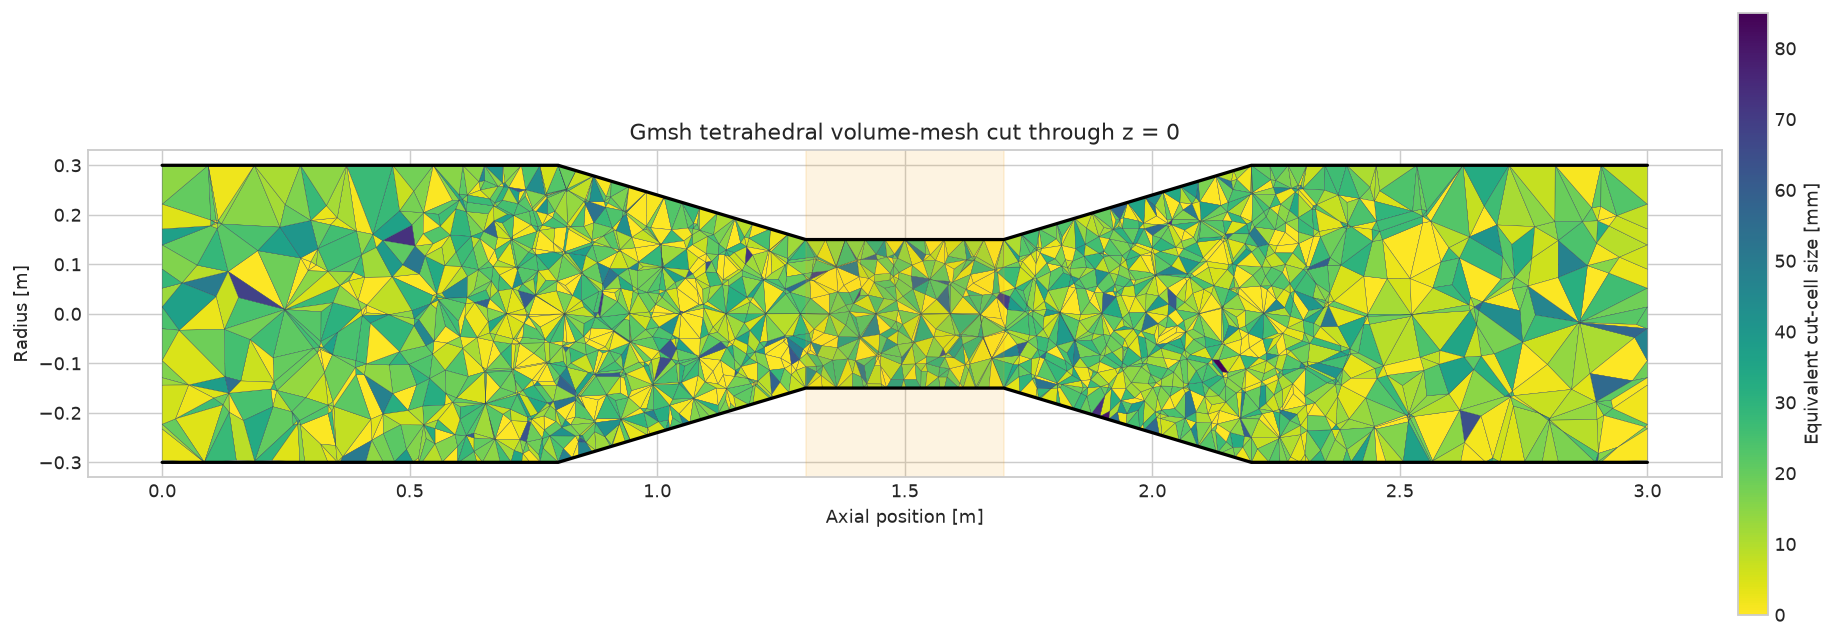

In [8]:
gmsh_mesh = pv.read(MSH_PATH)
mesh_slice = gmsh_mesh.slice(
    normal=(0.0, 0.0, 1.0),
)
slice_sizes = mesh_slice.compute_cell_sizes(
    length=False,
    area=True,
    volume=False,
)

faces = mesh_slice.faces
polygons = []
cursor = 0
while cursor < len(faces):
    vertex_count = int(faces[cursor])
    indices = faces[
        cursor + 1 : cursor + 1 + vertex_count
    ]
    polygons.append(
        mesh_slice.points[indices, :2]
    )
    cursor += vertex_count + 1

equivalent_size_mm = (
    1_000.0
    * np.sqrt(slice_sizes.cell_data["Area"])
)
collection = PolyCollection(
    polygons,
    array=equivalent_size_mm,
    cmap="viridis_r",
    edgecolor="#334155",
    linewidth=0.18,
)

figure, mesh_axis = plt.subplots(
    figsize=(14, 4.8),
    constrained_layout=True,
)
mesh_axis.add_collection(collection)
mesh_axis.autoscale_view()
mesh_axis.plot(
    X_SECTIONS_M,
    RADII_M,
    color="black",
    linewidth=1.8,
)
mesh_axis.plot(
    X_SECTIONS_M,
    -np.asarray(RADII_M),
    color="black",
    linewidth=1.8,
)
mesh_axis.axvspan(
    1.3,
    1.7,
    color="#f59e0b",
    alpha=0.12,
)
mesh_axis.set_aspect("equal", adjustable="box")
mesh_axis.set_xlabel("Axial position [m]")
mesh_axis.set_ylabel("Radius [m]")
mesh_axis.set_title(
    "Gmsh tetrahedral volume-mesh cut through z = 0"
)
figure.colorbar(
    collection,
    ax=mesh_axis,
    label="Equivalent cut-cell size [mm]",
    pad=0.01,
)
plt.show()

## 9. OpenFOAM environment and execution helpers

The helper sets the OpenFOAM environment explicitly, which works both for the
normal Colab installation and the isolated validation runtime. Every command
captures its output and fails immediately on a non-zero return code.

In [9]:
def foam_environment():
    library_root = (
        OPENFOAM_ROOT
        / "platforms"
        / OPENFOAM_PLATFORM
        / "lib"
    )
    binary_root = (
        OPENFOAM_ROOT
        / "platforms"
        / OPENFOAM_PLATFORM
        / "bin"
    )
    environment = os.environ.copy()
    environment.update(
        {
            "WM_PROJECT_DIR": str(OPENFOAM_ROOT),
            "WM_PROJECT_VERSION": "14",
            "WM_PROJECT": "OpenFOAM",
            "FOAM_ETC": str(OPENFOAM_ROOT / "etc"),
            "FOAM_APPBIN": str(binary_root),
            "FOAM_LIBBIN": str(library_root),
            "FOAM_TUTORIALS": str(
                OPENFOAM_ROOT / "tutorials"
            ),
            "PATH": (
                f"{binary_root}:"
                f"{OPENFOAM_ROOT / 'bin'}:"
                f"{environment['PATH']}"
            ),
            "LD_LIBRARY_PATH": (
                f"{library_root / 'dummy'}:"
                f"{library_root}:"
                f"{environment.get('LD_LIBRARY_PATH', '')}"
            ),
        }
    )
    return environment


def run_foam(command, timeout_seconds=1_800):
    working_directory = (
        CASE_DIR
        if CASE_DIR.is_dir()
        else RUNTIME_DIR
    )
    result = subprocess.run(
        command,
        cwd=working_directory,
        env=foam_environment(),
        check=False,
        text=True,
        capture_output=True,
        timeout=timeout_seconds,
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError(
            "OpenFOAM command failed: "
            + " ".join(command)
        )
    return result


def replace_wall_patch_type():
    boundary_path = (
        CASE_DIR
        / "constant"
        / "polyMesh"
        / "boundary"
    )
    source = boundary_path.read_text()
    pattern = r"(walls\s*\{.*?\btype\s+)patch(\s*;)"
    updated, replacement_count = re.subn(
        pattern,
        r"\1wall\2",
        source,
        flags=re.DOTALL,
    )
    if replacement_count != 1:
        raise RuntimeError(
            "Could not identify the walls patch"
        )
    boundary_path.write_text(updated)


foam_version = run_foam(
    ["foamRun", "-help"],
).stdout.splitlines()[-2]
print(foam_version)

Build: 14-7b05503f98a8


## 10. Create a transparent OpenFOAM case

The numerical controls use the OpenFOAM 14 steady incompressible-fluid
tutorial as their released-version basis. The case replaces the tutorial
geometry, fields, NeqSim viscosity, inlet velocity, and turbulence quantities.

The `k-epsilon` model is used for a compact workflow demonstration. Two
non-orthogonal pressure corrections are selected for the tetrahedral mesh.

In [10]:
def write_case_files():
    zero_dir = CASE_DIR / "0"
    system_dir = CASE_DIR / "system"
    constant_dir = CASE_DIR / "constant"
    zero_dir.mkdir(parents=True, exist_ok=True)
    system_dir.mkdir(parents=True, exist_ok=True)
    constant_dir.mkdir(parents=True, exist_ok=True)

    tutorial = (
        OPENFOAM_ROOT
        / "tutorials"
        / "incompressibleFluid"
        / "pitzDailySteady"
    )
    for name in (
        "controlDict",
        "fvSchemes",
        "fvSolution",
    ):
        shutil.copy(
            tutorial / "system" / name,
            system_dir / name,
        )
    for name in (
        "physicalProperties",
        "momentumTransport",
    ):
        shutil.copy(
            tutorial / "constant" / name,
            constant_dir / name,
        )

    physical_path = constant_dir / "physicalProperties"
    physical_source = physical_path.read_text()
    physical_source = re.sub(
        r"(?m)^nu\s+[^;]+;",
        (
            "nu              "
            f"{kinematic_viscosity_m2_per_s:.10g};"
        ),
        physical_source,
    )
    physical_path.write_text(physical_source)

    control_path = system_dir / "controlDict"
    control_source = control_path.read_text()
    control_source = re.sub(
        r"(?m)^endTime\s+[^;]+;",
        "endTime         1200;",
        control_source,
    )
    control_source = re.sub(
        r"(?m)^writeInterval\s+[^;]+;",
        "writeInterval   400;",
        control_source,
    )
    control_path.write_text(control_source)

    solution_path = system_dir / "fvSolution"
    solution_source = solution_path.read_text()
    solution_source = solution_source.replace(
        "solvers\n{",
        '''solvers
{
    Phi
    {
        solver          GAMG;
        smoother        DIC;
        tolerance       1e-06;
        relTol          0.01;
    }
''',
        1,
    )
    solution_source = solution_source.replace(
        "SIMPLE\n{",
        '''potentialFlow
{
    nNonOrthogonalCorrectors 2;
}

SIMPLE
{''',
        1,
    )
    solution_source = solution_source.replace(
        "nNonOrthogonalCorrectors 0;",
        "nNonOrthogonalCorrectors 2;",
    )
    solution_source = solution_source.replace(
        "relTol          0.1;",
        "relTol          0.05;",
    )
    solution_source = solution_source.replace(
        "U               1e-3;",
        "U               2e-3;",
    )
    solution_source = solution_source.replace(
        "U               0.9;",
        "U               0.7;",
    )
    solution_source = solution_source.replace(
        '".*"            0.9;',
        '".*"            0.7;',
    )
    solution_path.write_text(solution_source)

    velocity_field = f'''FoamFile
{{
    format ascii;
    class volVectorField;
    location "0";
    object U;
}}
dimensions [velocity];
internalField uniform ({openfoam_inlet_velocity_m_per_s:.10g} 0 0);
boundaryField
{{
    inlet
    {{
        type fixedValue;
        value uniform ({openfoam_inlet_velocity_m_per_s:.10g} 0 0);
    }}
    outlet
    {{
        type zeroGradient;
    }}
    walls
    {{
        type noSlip;
    }}
}}
'''
    pressure_field = '''FoamFile
{
    format ascii;
    class volScalarField;
    location "0";
    object p;
}
dimensions [kinematicPressure];
internalField uniform 0;
boundaryField
{
    inlet
    {
        type zeroGradient;
    }
    outlet
    {
        type fixedValue;
        value uniform 0;
    }
    walls
    {
        type zeroGradient;
    }
}
'''
    k_field = f'''FoamFile
{{
    format ascii;
    class volScalarField;
    location "0";
    object k;
}}
dimensions [turbulentKineticEnergy];
internalField uniform {openfoam_turbulent_k_m2_per_s2:.10g};
boundaryField
{{
    inlet
    {{
        type fixedValue;
        value uniform {openfoam_turbulent_k_m2_per_s2:.10g};
    }}
    outlet
    {{
        type inletOutlet;
        inletValue uniform {openfoam_turbulent_k_m2_per_s2:.10g};
        value uniform {openfoam_turbulent_k_m2_per_s2:.10g};
    }}
    walls
    {{
        type kqRWallFunction;
        value uniform {openfoam_turbulent_k_m2_per_s2:.10g};
    }}
}}
'''
    epsilon_field = f'''FoamFile
{{
    format ascii;
    class volScalarField;
    location "0";
    object epsilon;
}}
dimensions [turbulentEpsilon];
internalField uniform {openfoam_turbulent_epsilon_m2_per_s3:.10g};
boundaryField
{{
    inlet
    {{
        type fixedValue;
        value uniform {openfoam_turbulent_epsilon_m2_per_s3:.10g};
    }}
    outlet
    {{
        type inletOutlet;
        inletValue uniform {openfoam_turbulent_epsilon_m2_per_s3:.10g};
        value uniform {openfoam_turbulent_epsilon_m2_per_s3:.10g};
    }}
    walls
    {{
        type epsilonWallFunction;
        value uniform {openfoam_turbulent_epsilon_m2_per_s3:.10g};
    }}
}}
'''
    nut_field = '''FoamFile
{
    format ascii;
    class volScalarField;
    location "0";
    object nut;
}
dimensions [kinematicViscosity];
internalField uniform 0;
boundaryField
{
    inlet
    {
        type calculated;
        value uniform 0;
    }
    outlet
    {
        type calculated;
        value uniform 0;
    }
    walls
    {
        type nutkWallFunction;
        value uniform 0;
    }
}
'''
    fields = {
        "U": velocity_field,
        "p": pressure_field,
        "k": k_field,
        "epsilon": epsilon_field,
        "nut": nut_field,
    }
    for field_name, field_source in fields.items():
        (zero_dir / field_name).write_text(
            field_source
        )


print(
    "Case writer prepared for "
    f"{kinematic_viscosity_m2_per_s:.4e} m2/s"
)

Case writer prepared for 7.4902e-07 m2/s


## 11. Convert, check, initialize, and solve

`gmshToFoam` converts the physical names to boundary patches. `checkMesh`
provides the topology and geometry gate. Potential flow supplies a stable
initial velocity field before the steady RANS solve.

Only concise convergence evidence is printed; complete command logs remain in
the generated case directory.

In [11]:
CASE_DIR.mkdir(parents=True)
write_case_files()

conversion_result = run_foam(
    [
        "gmshToFoam",
        str(MSH_PATH),
        "-case",
        str(CASE_DIR),
    ]
)
(CASE_DIR / "log.gmshToFoam").write_text(
    conversion_result.stdout
)
replace_wall_patch_type()

mesh_check = run_foam(
    [
        "checkMesh",
        "-case",
        str(CASE_DIR),
    ]
)
(CASE_DIR / "log.checkMesh").write_text(
    mesh_check.stdout
)
if "Mesh OK." not in mesh_check.stdout:
    raise RuntimeError("OpenFOAM mesh check did not pass")

potential_result = run_foam(
    [
        "potentialFoam",
        "-case",
        str(CASE_DIR),
        "-initialiseUBCs",
    ]
)
(CASE_DIR / "log.potentialFoam").write_text(
    potential_result.stdout
)

solver_result = run_foam(
    [
        "foamRun",
        "-case",
        str(CASE_DIR),
        "-solver",
        "incompressibleFluid",
    ],
    timeout_seconds=1_800,
)
(CASE_DIR / "log.foamRun").write_text(
    solver_result.stdout
)

convergence_match = re.search(
    r"SIMPLE solution converged in\s+(\d+) iterations",
    solver_result.stdout,
)
if convergence_match is None:
    raise RuntimeError(
        "The steady OpenFOAM solution did not converge"
    )
solver_iterations = int(convergence_match.group(1))

vtk_result = run_foam(
    [
        "foamToVTK",
        "-case",
        str(CASE_DIR),
        "-latestTime",
    ]
)
(CASE_DIR / "log.foamToVTK").write_text(
    vtk_result.stdout
)
latest_time = run_foam(
    [
        "foamListTimes",
        "-case",
        str(CASE_DIR),
        "-latestTime",
    ]
).stdout.strip()


def extract_check_value(pattern, text):
    match = re.search(pattern, text)
    if match is None:
        raise RuntimeError(
            f"Mesh-check value not found: {pattern}"
        )
    return float(match.group(1))


check_table = pd.Series(
    {
        "OpenFOAM cells [-]": extract_check_value(
            r"cells:\s+(\d+)",
            mesh_check.stdout,
        ),
        "maximum aspect ratio [-]": extract_check_value(
            r"Max aspect ratio =\s*([0-9.eE+-]+)",
            mesh_check.stdout,
        ),
        "maximum non-orthogonality [deg]": (
            extract_check_value(
                r"Mesh non-orthogonality Max:\s*"
                r"([0-9.eE+-]+)",
                mesh_check.stdout,
            )
        ),
        "maximum skewness [-]": extract_check_value(
            r"Max skewness =\s*([0-9.eE+-]+)",
            mesh_check.stdout,
        ),
        "solver iterations [-]": solver_iterations,
        "latest time index [-]": float(latest_time),
        "mesh check passed": True,
        "steady convergence reported": True,
    },
    name="OpenFOAM execution",
)
check_table

OpenFOAM cells [-]                  24,410
maximum aspect ratio [-]           7.58286
maximum non-orthogonality [deg]    65.3251
maximum skewness [-]              0.878918
solver iterations [-]                  457
latest time index [-]                  457
mesh check passed                     True
steady convergence reported           True
Name: OpenFOAM execution, dtype: object

## 12. Recover flow and pressure checks

OpenFOAM stores incompressible pressure as kinematic pressure. The physical
pressure difference is recovered with the NeqSim density:

$$
\Delta p = \rho\,\Delta p_{\mathrm{kin}}.
$$

The inlet process pressure is the absolute reference. Patch-integrated fluxes
provide an independent volume and mass-conservation check.

In [12]:
post_process_commands = {
    "inletFlow": (
        "patchFlowRate("
        "name=inletFlow,"
        "patch=inlet)"
    ),
    "outletFlow": (
        "patchFlowRate("
        "name=outletFlow,"
        "patch=outlet)"
    ),
    "inletPressure": (
        "patchAverage("
        "name=inletPressure,"
        "patch=inlet,"
        "fields=(p))"
    ),
    "outletPressure": (
        "patchAverage("
        "name=outletPressure,"
        "patch=outlet,"
        "fields=(p))"
    ),
}
for result_name, function_expression in (
    post_process_commands.items()
):
    run_foam(
        [
            "foamPostProcess",
            "-case",
            str(CASE_DIR),
            "-latestTime",
            "-func",
            function_expression,
        ]
    )


def read_surface_value(result_name):
    result_files = list(
        (
            CASE_DIR
            / "postProcessing"
            / result_name
        ).glob("*/surfaceFieldValue.dat")
    )
    if len(result_files) != 1:
        raise RuntimeError(
            f"Unexpected outputs for {result_name}"
        )
    data_lines = [
        line
        for line in result_files[0].read_text().splitlines()
        if line.strip()
        and not line.lstrip().startswith("#")
    ]
    return float(data_lines[-1].split()[-1])


inlet_flow_m3_per_s = abs(
    read_surface_value("inletFlow")
)
outlet_flow_m3_per_s = abs(
    read_surface_value("outletFlow")
)
inlet_kinematic_pressure_m2_per_s2 = (
    read_surface_value("inletPressure")
)
outlet_kinematic_pressure_m2_per_s2 = (
    read_surface_value("outletPressure")
)

flow_closure_relative = abs(
    outlet_flow_m3_per_s - inlet_flow_m3_per_s
) / inlet_flow_m3_per_s
pressure_loss_pa = (
    density_kg_per_m3
    * (
        inlet_kinematic_pressure_m2_per_s2
        - outlet_kinematic_pressure_m2_per_s2
    )
)
mass_flow_cfd_kg_per_s = (
    density_kg_per_m3
    * outlet_flow_m3_per_s
)
mass_flow_difference_relative = abs(
    mass_flow_cfd_kg_per_s - mass_flow_kg_per_s
) / mass_flow_kg_per_s

validation_table = pd.Series(
    {
        "NeqSim actual flow [m3/s]": actual_flow_m3_per_s,
        "OpenFOAM inlet flow [m3/s]": inlet_flow_m3_per_s,
        "OpenFOAM outlet flow [m3/s]": outlet_flow_m3_per_s,
        "OpenFOAM flow closure [-]": flow_closure_relative,
        "NeqSim mass flow [kg/s]": mass_flow_kg_per_s,
        "CFD outlet mass flow [kg/s]": mass_flow_cfd_kg_per_s,
        "NeqSim-CFD mass-flow difference [-]": (
            mass_flow_difference_relative
        ),
        "recovered pressure loss [Pa]": pressure_loss_pa,
    },
    name="Cross-tool validation",
)
validation_table

NeqSim actual flow [m3/s]                0.696119
OpenFOAM inlet flow [m3/s]               0.696119
OpenFOAM outlet flow [m3/s]              0.696113
OpenFOAM flow closure [-]             8.47556e-06
NeqSim mass flow [kg/s]                   10.7702
CFD outlet mass flow [kg/s]               10.7702
NeqSim-CFD mass-flow difference [-]   8.90517e-06
recovered pressure loss [Pa]              273.019
Name: Cross-tool validation, dtype: float64

## 13. Render the actual CFD solution

The volume result is sampled onto the axial mid-plane. Pressure is plotted
relative to the NeqSim inlet state, so acceleration through the throat and
irreversible pressure loss after recovery remain visible despite the 20 bara
absolute operating pressure.

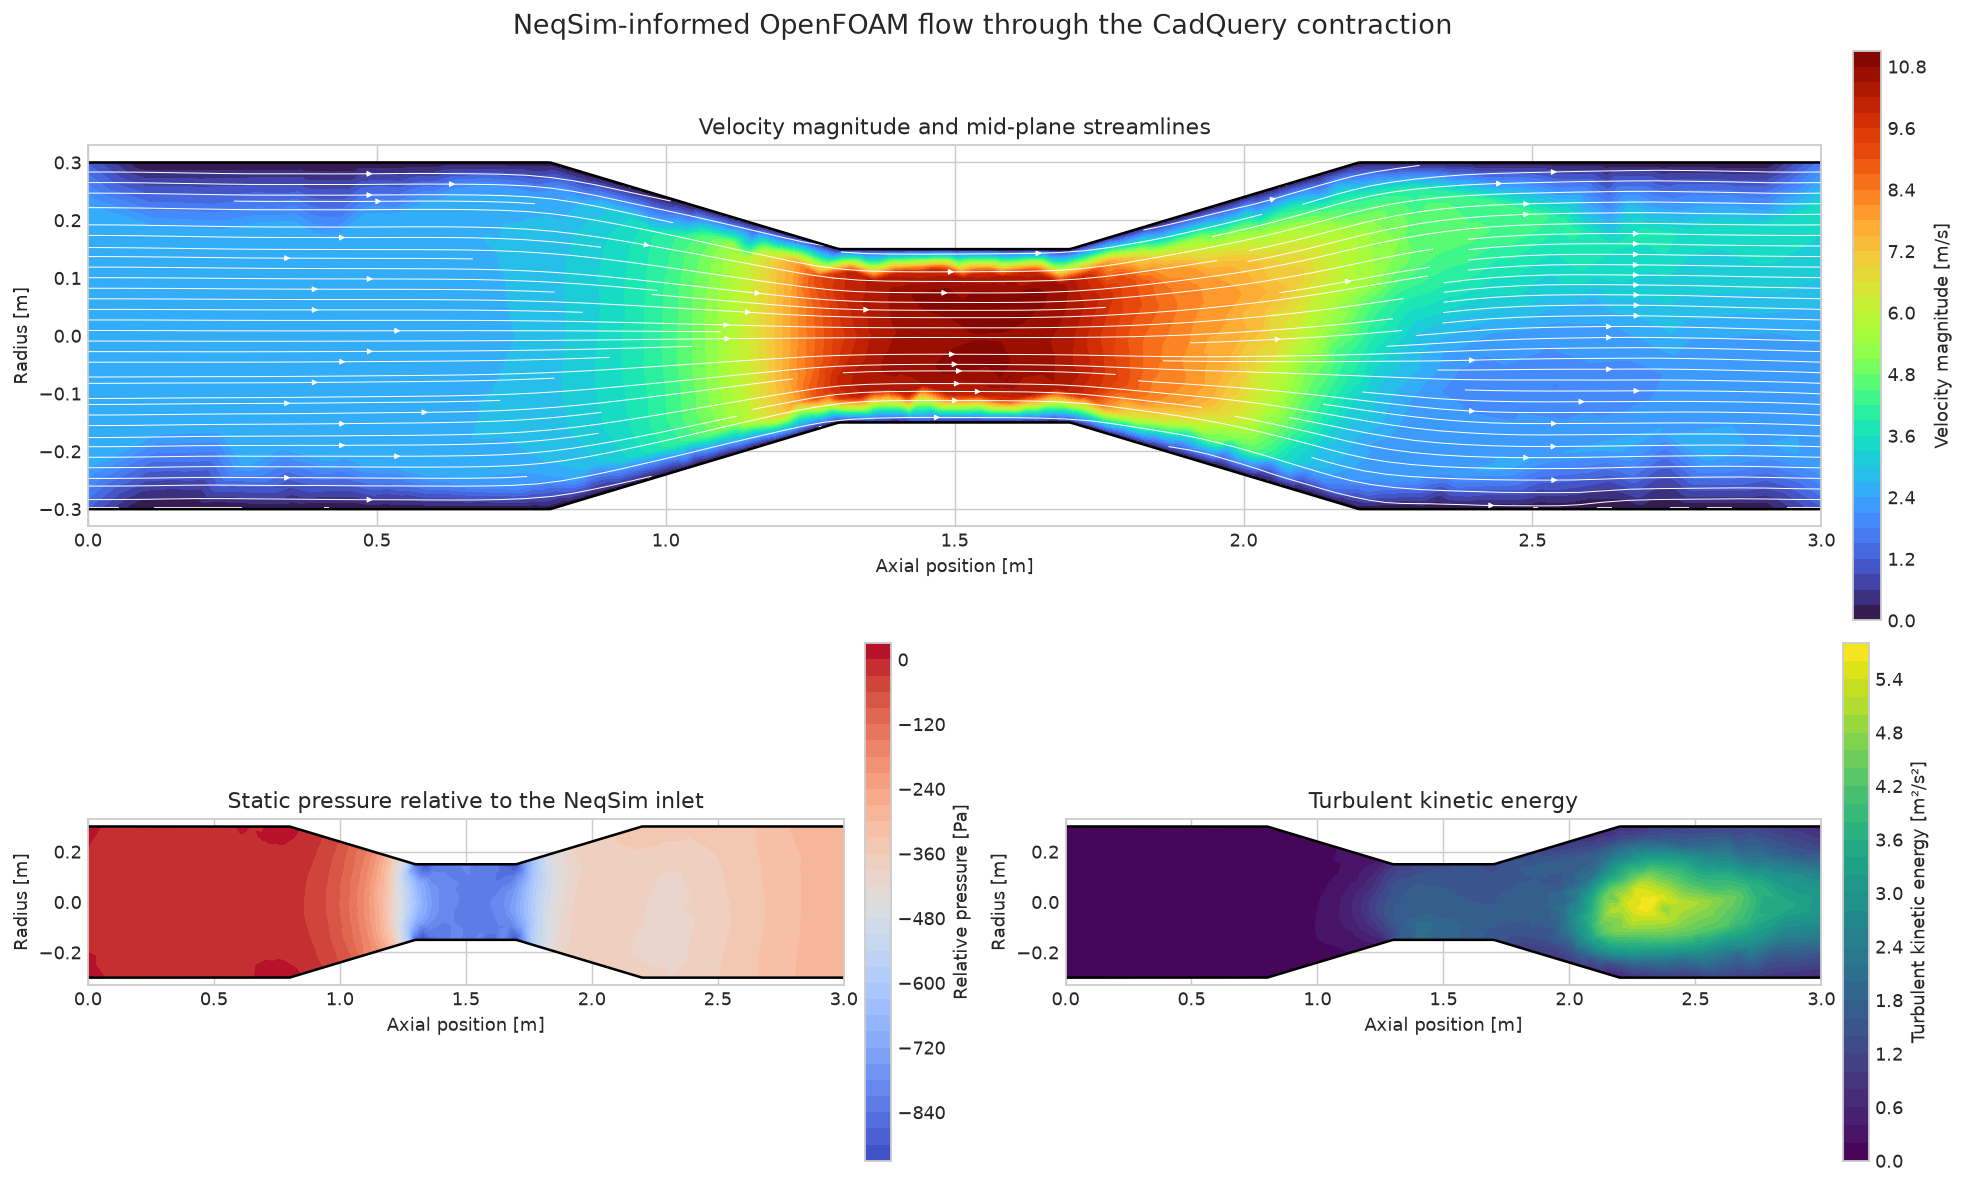

In [13]:
vtk_path = (
    CASE_DIR
    / "VTK"
    / f"{CASE_DIR.name}_{latest_time}.vtk"
)
solution_mesh = pv.read(vtk_path)

x_values_m = np.linspace(0.0, 3.0, 520)
y_values_m = np.linspace(-0.32, 0.32, 180)
x_grid_m, y_grid_m = np.meshgrid(
    x_values_m,
    y_values_m,
)
sample_coordinates = np.column_stack(
    [
        x_grid_m.ravel(),
        y_grid_m.ravel(),
        np.zeros(x_grid_m.size),
    ]
)
sampled = pv.PolyData(sample_coordinates).sample(
    solution_mesh
)
valid_mask = sampled.point_data[
    "vtkValidPointMask"
].reshape(x_grid_m.shape).astype(bool)
velocity_vectors = sampled.point_data["U"].reshape(
    *x_grid_m.shape,
    3,
)
kinematic_pressure = sampled.point_data["p"].reshape(
    x_grid_m.shape
)
turbulent_k = sampled.point_data["k"].reshape(
    x_grid_m.shape
)

speed_m_per_s = np.linalg.norm(
    velocity_vectors,
    axis=2,
)
relative_pressure_pa = (
    density_kg_per_m3
    * (
        kinematic_pressure
        - inlet_kinematic_pressure_m2_per_s2
    )
)
speed_field = np.ma.masked_where(
    ~valid_mask,
    speed_m_per_s,
)
pressure_field = np.ma.masked_where(
    ~valid_mask,
    relative_pressure_pa,
)
k_field = np.ma.masked_where(
    ~valid_mask,
    turbulent_k,
)
u_field = np.ma.masked_where(
    ~valid_mask,
    velocity_vectors[:, :, 0],
)
v_field = np.ma.masked_where(
    ~valid_mask,
    velocity_vectors[:, :, 1],
)


def radius_at_x(x_values):
    return np.interp(
        x_values,
        X_SECTIONS_M,
        RADII_M,
    )


def draw_geometry_outline(axis):
    smooth_x = np.linspace(0.0, 3.0, 600)
    smooth_radius = radius_at_x(smooth_x)
    axis.plot(
        smooth_x,
        smooth_radius,
        color="black",
        linewidth=1.4,
    )
    axis.plot(
        smooth_x,
        -smooth_radius,
        color="black",
        linewidth=1.4,
    )
    axis.set_xlim(0.0, 3.0)
    axis.set_ylim(-0.33, 0.33)
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("Axial position [m]")
    axis.set_ylabel("Radius [m]")


figure = plt.figure(
    figsize=(15, 9),
    constrained_layout=True,
)
grid = figure.add_gridspec(
    2,
    2,
    height_ratios=[1.1, 1.0],
)

speed_axis = figure.add_subplot(grid[0, :])
speed_contours = speed_axis.contourf(
    x_values_m,
    y_values_m,
    speed_field,
    levels=36,
    cmap="turbo",
)
speed_axis.streamplot(
    x_values_m,
    y_values_m,
    u_field,
    v_field,
    color="white",
    density=(2.1, 1.2),
    linewidth=0.55,
    arrowsize=0.65,
)
draw_geometry_outline(speed_axis)
speed_axis.set_title(
    "Velocity magnitude and mid-plane streamlines"
)
figure.colorbar(
    speed_contours,
    ax=speed_axis,
    label="Velocity magnitude [m/s]",
    pad=0.01,
)

pressure_axis = figure.add_subplot(grid[1, 0])
pressure_contours = pressure_axis.contourf(
    x_values_m,
    y_values_m,
    pressure_field,
    levels=36,
    cmap="coolwarm",
)
draw_geometry_outline(pressure_axis)
pressure_axis.set_title(
    "Static pressure relative to the NeqSim inlet"
)
figure.colorbar(
    pressure_contours,
    ax=pressure_axis,
    label="Relative pressure [Pa]",
    pad=0.01,
)

k_axis = figure.add_subplot(grid[1, 1])
k_contours = k_axis.contourf(
    x_values_m,
    y_values_m,
    k_field,
    levels=36,
    cmap="viridis",
)
draw_geometry_outline(k_axis)
k_axis.set_title("Turbulent kinetic energy")
figure.colorbar(
    k_contours,
    ax=k_axis,
    label="Turbulent kinetic energy [m²/s²]",
    pad=0.01,
)

figure.suptitle(
    "NeqSim-informed OpenFOAM flow through "
    "the CadQuery contraction",
    fontsize=15,
)
plt.show()

## 14. Engineering interpretation and executable checks

The centerline view is compared with the ideal bulk velocity from continuity.
Centerline velocity is expected to exceed bulk velocity in the developed
profile. The static-pressure minimum should occur in or immediately around the
throat, followed by partial recovery and a finite outlet loss.

The assertions verify geometry identity, mesh health, steady convergence,
cross-tool flow closure, positive turbulence fields, low Mach number, and
physically consistent contraction trends.

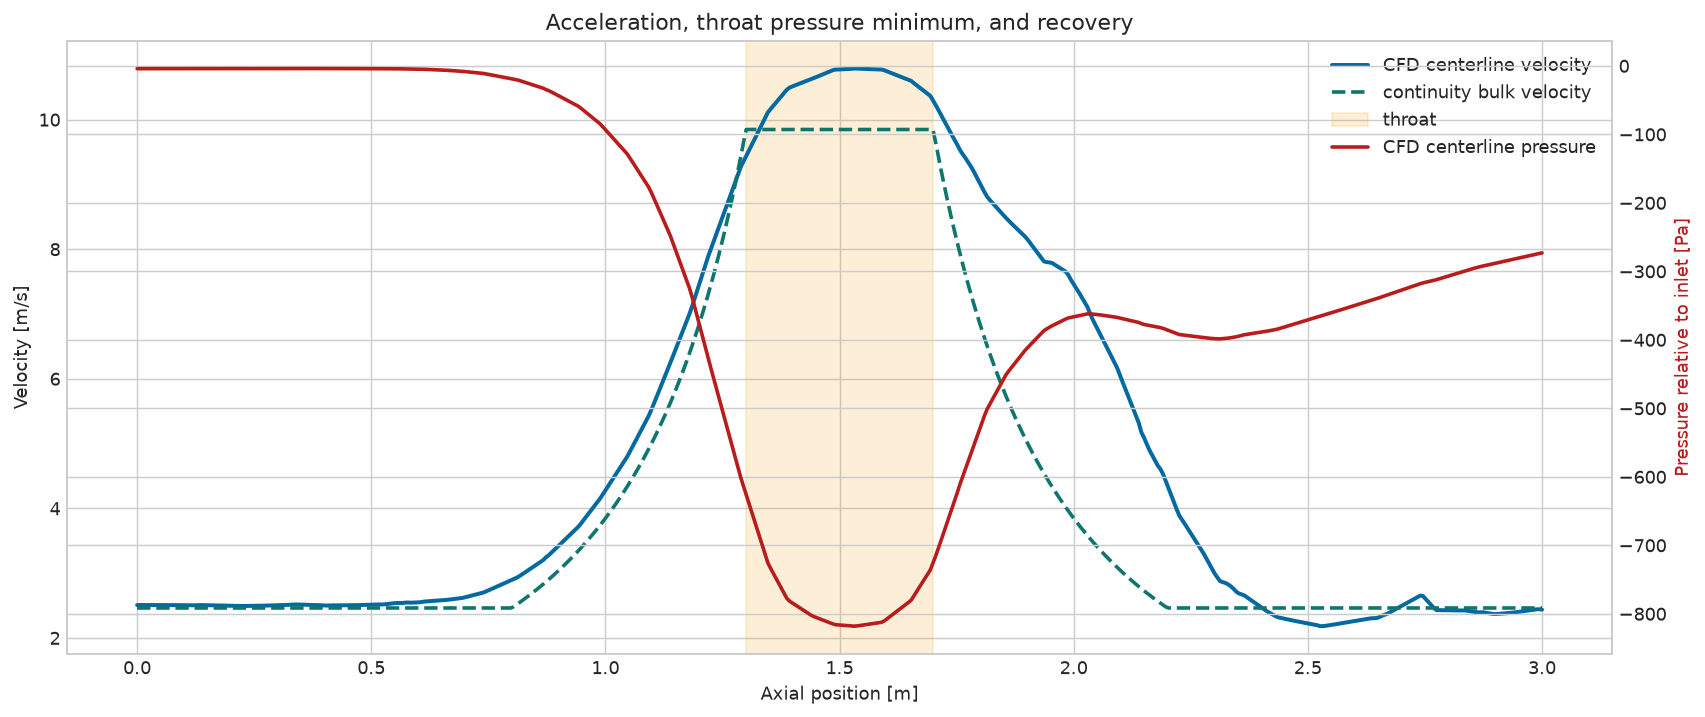

CAD/analytical volume error [-]   3.43937e-16
OpenFOAM mesh cells [-]                 24410
solver iterations [-]                     457
flow closure [%]                  0.000847556
pressure loss [Pa]                    273.019
maximum speed [m/s]                   12.7349
maximum Mach number [-]             0.0311479
pressure-minimum x [m]                1.53179
minimum final k [m2/s2]             0.0140158
minimum final epsilon [m2/s3]      0.00515919
all engineering checks passed            True
Name: Final engineering validation, dtype: object

In [14]:
centerline_coordinates = np.column_stack(
    [
        x_values_m,
        np.zeros_like(x_values_m),
        np.zeros_like(x_values_m),
    ]
)
centerline_sample = pv.PolyData(
    centerline_coordinates
).sample(solution_mesh)
centerline_velocity_m_per_s = np.linalg.norm(
    centerline_sample.point_data["U"],
    axis=1,
)
centerline_pressure_pa = (
    density_kg_per_m3
    * (
        centerline_sample.point_data["p"]
        - inlet_kinematic_pressure_m2_per_s2
    )
)
ideal_bulk_velocity_m_per_s = (
    actual_flow_m3_per_s
    / (
        math.pi
        * radius_at_x(x_values_m) ** 2
    )
)

figure, profile_axis = plt.subplots(
    figsize=(13, 5.4),
    constrained_layout=True,
)
pressure_profile_axis = profile_axis.twinx()
profile_axis.plot(
    x_values_m,
    centerline_velocity_m_per_s,
    color="#0369a1",
    linewidth=2.2,
    label="CFD centerline velocity",
)
profile_axis.plot(
    x_values_m,
    ideal_bulk_velocity_m_per_s,
    color="#0f766e",
    linestyle="--",
    linewidth=2.0,
    label="continuity bulk velocity",
)
pressure_profile_axis.plot(
    x_values_m,
    centerline_pressure_pa,
    color="#b91c1c",
    linewidth=2.0,
    label="CFD centerline pressure",
)
profile_axis.axvspan(
    1.3,
    1.7,
    color="#f59e0b",
    alpha=0.16,
    label="throat",
)
profile_axis.set_xlabel("Axial position [m]")
profile_axis.set_ylabel("Velocity [m/s]")
pressure_profile_axis.set_ylabel(
    "Pressure relative to inlet [Pa]",
    color="#b91c1c",
)
profile_axis.set_title(
    "Acceleration, throat pressure minimum, and recovery"
)
lines_1, labels_1 = profile_axis.get_legend_handles_labels()
lines_2, labels_2 = (
    pressure_profile_axis.get_legend_handles_labels()
)
profile_axis.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right",
)
plt.show()

maximum_velocity_m_per_s = float(
    np.max(solution_mesh.cell_data["U"], axis=0)[0]
)
maximum_speed_m_per_s = float(
    np.linalg.norm(
        solution_mesh.cell_data["U"],
        axis=1,
    ).max()
)
maximum_mach_number = (
    maximum_speed_m_per_s / sound_speed_m_per_s
)
minimum_pressure_x_m = x_values_m[
    np.argmin(centerline_pressure_pa)
]
minimum_k = float(
    solution_mesh.cell_data["k"].min()
)
minimum_epsilon = float(
    solution_mesh.cell_data["epsilon"].min()
)

assert cad_volume_error_relative < 1.0e-10
assert "Mesh OK." in mesh_check.stdout
assert convergence_match is not None
assert flow_closure_relative < 1.0e-3
assert mass_flow_difference_relative < 1.0e-3
assert minimum_k > 0.0
assert minimum_epsilon > 0.0
assert maximum_mach_number < 0.10
assert 1.20 < minimum_pressure_x_m < 1.90
assert centerline_velocity_m_per_s.max() > (
    3.0 * inlet_velocity_m_per_s
)
assert pressure_loss_pa > 0.0

final_summary = pd.Series(
    {
        "CAD/analytical volume error [-]": (
            cad_volume_error_relative
        ),
        "OpenFOAM mesh cells [-]": mesh_cell_count,
        "solver iterations [-]": solver_iterations,
        "flow closure [%]": 100.0 * flow_closure_relative,
        "pressure loss [Pa]": pressure_loss_pa,
        "maximum speed [m/s]": maximum_speed_m_per_s,
        "maximum Mach number [-]": maximum_mach_number,
        "pressure-minimum x [m]": minimum_pressure_x_m,
        "minimum final k [m2/s2]": minimum_k,
        "minimum final epsilon [m2/s3]": minimum_epsilon,
        "all engineering checks passed": True,
    },
    name="Final engineering validation",
)
final_summary

## 15. Package the reusable artifacts

The ZIP contains the STEP master, named STL boundaries, Gmsh mesh, OpenFOAM
case dictionaries, solution, logs, and VTK results. In Colab, select the link
below to download the full case. The key geometry, mesh, numerical results,
and validation evidence are already embedded above.

In [15]:
coupling_csv_path = (
    RUNTIME_DIR / "neqsim_openfoam_coupling.csv"
)
coupling_table.to_csv(
    coupling_csv_path,
    header=["value"],
)

archive_base = RUNTIME_PARENT / "neqsim_cad_cfd_workflow"
archive_path = Path(
    shutil.make_archive(
        str(archive_base),
        "zip",
        root_dir=RUNTIME_DIR,
    )
)

artifact_table = pd.DataFrame(
    [
        {
            "artifact": STEP_PATH.name,
            "purpose": "accurate editable CAD master",
            "size [kB]": STEP_PATH.stat().st_size / 1_024.0,
        },
        {
            "artifact": MSH_PATH.name,
            "purpose": "named Gmsh volume mesh",
            "size [kB]": MSH_PATH.stat().st_size / 1_024.0,
        },
        {
            "artifact": archive_path.name,
            "purpose": "complete reusable workflow",
            "size [kB]": archive_path.stat().st_size / 1_024.0,
        },
    ]
)
display(artifact_table)

try:
    from IPython.display import FileLink

    display(
        FileLink(
            archive_path,
            result_html_prefix="Download: ",
        )
    )
except ImportError:
    print(f"Archive: {archive_path}")

,artifact,purpose,size [kB]
0,contraction_fluid_domain.step,accurate editable CAD master,15.8145
1,contraction_fluid_domain.msh,named Gmsh volume mesh,"1,242.87"
2,neqsim_cad_cfd_workflow.zip,complete reusable workflow,"4,687.22"


/workspace/scratch/414b0104c46c/neqsim_cad_cfd_workflow.zip

## Conclusions

- CadQuery produced an exact, parameter-controlled B-Rep internal fluid volume
  and reusable STEP master.
- Named surfaces survived STEP-to-Gmsh-to-OpenFOAM conversion as `inlet`,
  `outlet`, and `walls`.
- NeqSim supplied the real-gas phase state, density, viscosity, heat capacity,
  conductivity, sound speed, actual flow, and mass flow.
- OpenFOAM resolved acceleration through the throat, the pressure minimum,
  downstream recovery, and a finite irreversible loss.
- CAD volume identity, mesh quality, steady convergence, flow closure,
  NeqSim-to-CFD mass-flow transfer, Mach number, and final turbulence fields
  were all checked by executable assertions.

## Limitations and next steps

This is a one-way, isothermal, constant-property RANS workflow. The mesh has no
wall-normal prism layers, and no mesh-independence, $y^+$, turbulence-model, or
experimental validation study is claimed. It is suitable for teaching and
workflow verification, not mechanical design or equipment certification.

Strong extensions are:

1. add prism layers and compare three mesh levels;
2. replace the simple contraction with a valve, scrubber, or separator;
3. use pressure- and temperature-dependent NeqSim property tables;
4. add Euler-Lagrange droplets or Euler-Euler phases;
5. fit CFD pressure-loss or separation-efficiency correlations and return them
   to a composable NeqSim unit operation.

## References

- [CadQuery documentation](https://cadquery.readthedocs.io/)
- [CadQuery import and export formats](https://cadquery.readthedocs.io/en/latest/importexport.html)
- [Gmsh reference manual](https://gmsh.info/doc/texinfo/)
- [OpenFOAM Foundation](https://openfoam.org/)
- [OpenFOAM 14 installation](https://openfoam.org/download/14-ubuntu/)
- [NeqSim documentation](https://equinor.github.io/neqsim/)